# Model training

Static ML → Ensemble ML → Temporal DL

- There are individual features in each cycle that might give different results when fitting the model. 

In [47]:
#importing libraries
import pandas as pd 
import numpy as np 
import os 
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
import utils
import importlib
from scipy.optimize import curve_fit
from pybaselines import Baseline
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
from sklearn.metrics import (mean_absolute_error,r2_score)
from sklearn.ensemble import AdaBoostRegressor
from sklearn import preprocessing
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error,r2_score, classification_report, accuracy_score, f1_score)
from sklearn.linear_model import RANSACRegressor

In [105]:
importlib.reload(utils)
from utils import time_format,preprocessing_meta,battery_cycles_df,continuous_time,current_capacity,visualization_2by2, timeTmax, time_Tmax3,area_under_curve, time_to_voltage, charging_decay, charging_slope, ransac_clean_outliers

In [49]:
meta = pd.read_csv("metadata.csv")
#Correcting time format
meta = time_format(meta)
#Correcting formats
meta = preprocessing_meta(meta)

# Static ML

## Charging cycles

List of features: 
- exponential curve fitting
- Peak detection for the maximum temperature (~~)
- Time to reach 4.2 V
- Time of maximum temperature
- Charging duration (under constant voltage)
- test_id

Target: 
-SoH/test  

In [50]:
#Selection of battery set
B_batch1 = ["B0005","B0006","B0007","B0018"]
#Subset of data for charging cycles
B1_charge = battery_cycles_df(meta, B_batch1, "charge")
#Calculating the capacity
B1_charge = continuous_time(B1_charge)
B1_charge = current_capacity(B1_charge)


In [51]:
B1_charge.columns

Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_charge', 'Voltage_charge', 'Time', 'type', 'test_id',
       'battery_id', 'start_time', 'real_time', 'norm_time', 'capacity_Ah'],
      dtype='str')

In [52]:
grouped = B1_charge.groupby(["battery_id", "test_id"])
len(grouped)

644

In [53]:
#Extracting the initial capacity for each battery 

iCap_idx = B1_charge.loc[B1_charge["test_id"]==2].groupby("battery_id")["capacity_Ah"].idxmax()
iCap_B0018= B1_charge.loc[((B1_charge["battery_id"]=="B0018")&(B1_charge["test_id"]==4))].groupby("battery_id")["capacity_Ah"].idxmax()
iCap_idx = pd.concat([iCap_idx,iCap_B0018])

#Locate the capacity value at each index
iCap = (B1_charge.loc[iCap_idx, ["battery_id", "capacity_Ah"]].set_index("battery_id")["capacity_Ah"])

#Use value to calculate the SoH per cycle
B1_charge["SoH"] = B1_charge["capacity_Ah"]/B1_charge["battery_id"].map(iCap)*100


In [54]:
#The maximum temperature is not optimized for each cycle. Needs more work
results_Tmax = timeTmax(B1_charge)

In [55]:
len(results_Tmax)

644

In [56]:
results_Time_to_voltage = time_to_voltage(B1_charge)
len(results_Time_to_voltage)

644

In [57]:
results_charge_decay = charging_decay(B1_charge)
len(results_charge_decay)

644

In [58]:
results_charge_decay

,battery_id,test_id,exp_coefficient
0,B0005,0,0.000915
1,B0005,2,0.000934
2,B0005,4,0.000933
3,B0005,6,0.000933
4,B0005,8,0.000930
...,...,...,...
639,B0018,307,0.000778
640,B0018,309,0.000787
641,B0018,311,0.000777
642,B0018,315,0.000755


In [59]:
results_thermal_area = area_under_curve(df=B1_charge, x= "Time",y="Temperature_measured")
len(results_thermal_area)

644

In [60]:
results_CCslope = charging_slope(B1_charge)
len(results_CCslope)

644

In [61]:
#Extracting the SoH

iCap_idx = B1_charge.loc[B1_charge["test_id"]==2].groupby("battery_id")["capacity_Ah"].idxmax()
iCap_B0018= B1_charge.loc[((B1_charge["battery_id"]=="B0018")&(B1_charge["test_id"]==4))].groupby("battery_id")["capacity_Ah"].idxmax()
iCap_idx = pd.concat([iCap_idx,iCap_B0018])

#Locate the capacity value at each index
iCap = (B1_charge.loc[iCap_idx, ["battery_id", "capacity_Ah"]].set_index("battery_id")["capacity_Ah"])

#Use value to calculate the SoH per cycle
B1_charge["SoH"] = B1_charge["capacity_Ah"]/B1_charge["battery_id"].map(iCap)*100
SoH = (B1_charge.groupby(["battery_id", "test_id"], as_index=False).agg({"SoH": "last"}))

In [62]:
len(SoH)

644

In [63]:
results_CCslope.columns

Index(['battery_id', 'test_id', 'slope', 'intercept'], dtype='str')

In [64]:
charge_summary= pd.concat([results_Time_to_voltage,results_Tmax[["time_Tmax","T_peak"]]], axis=1,join="inner")
charge_summary = pd.concat([charge_summary,results_charge_decay["exp_coefficient"]], axis=1,join="inner")

charge_summary = pd.concat([charge_summary,results_thermal_area["Area_Under_curve"]], axis=1,join="inner")
charge_summary = pd.concat([charge_summary,results_CCslope["slope"]], axis=1,join="inner")
charge_summary = pd.concat([charge_summary,results_CCslope["intercept"]], axis=1,join="inner")
charge_summary = pd.concat([charge_summary,SoH["SoH"]], axis=1,join="inner")

In [65]:
charge_summary.isna().sum()

battery_id          0
test_id             0
time_to_4p2V        3
time_Tmax           8
T_peak              8
exp_coefficient     3
Area_Under_curve    1
slope               0
intercept           0
SoH                 0
dtype: int64

In [66]:
charge_summary['time_to_4p2V'] = charge_summary['time_to_4p2V'].interpolate(method='linear')
charge_summary['time_Tmax'] = charge_summary['time_Tmax'].interpolate(method='linear')
charge_summary['T_peak'] = charge_summary['T_peak'].interpolate(method='linear')
charge_summary['exp_coefficient'] = charge_summary['exp_coefficient'].interpolate(method='linear')
charge_summary['Area_Under_curve'] = charge_summary['Area_Under_curve'].interpolate(method='linear')

In [67]:
charge_summary.isna().sum()

battery_id          0
test_id             0
time_to_4p2V        0
time_Tmax           0
T_peak              0
exp_coefficient     0
Area_Under_curve    0
slope               0
intercept           0
SoH                 0
dtype: int64

<Axes: xlabel='test_id', ylabel='SoH'>

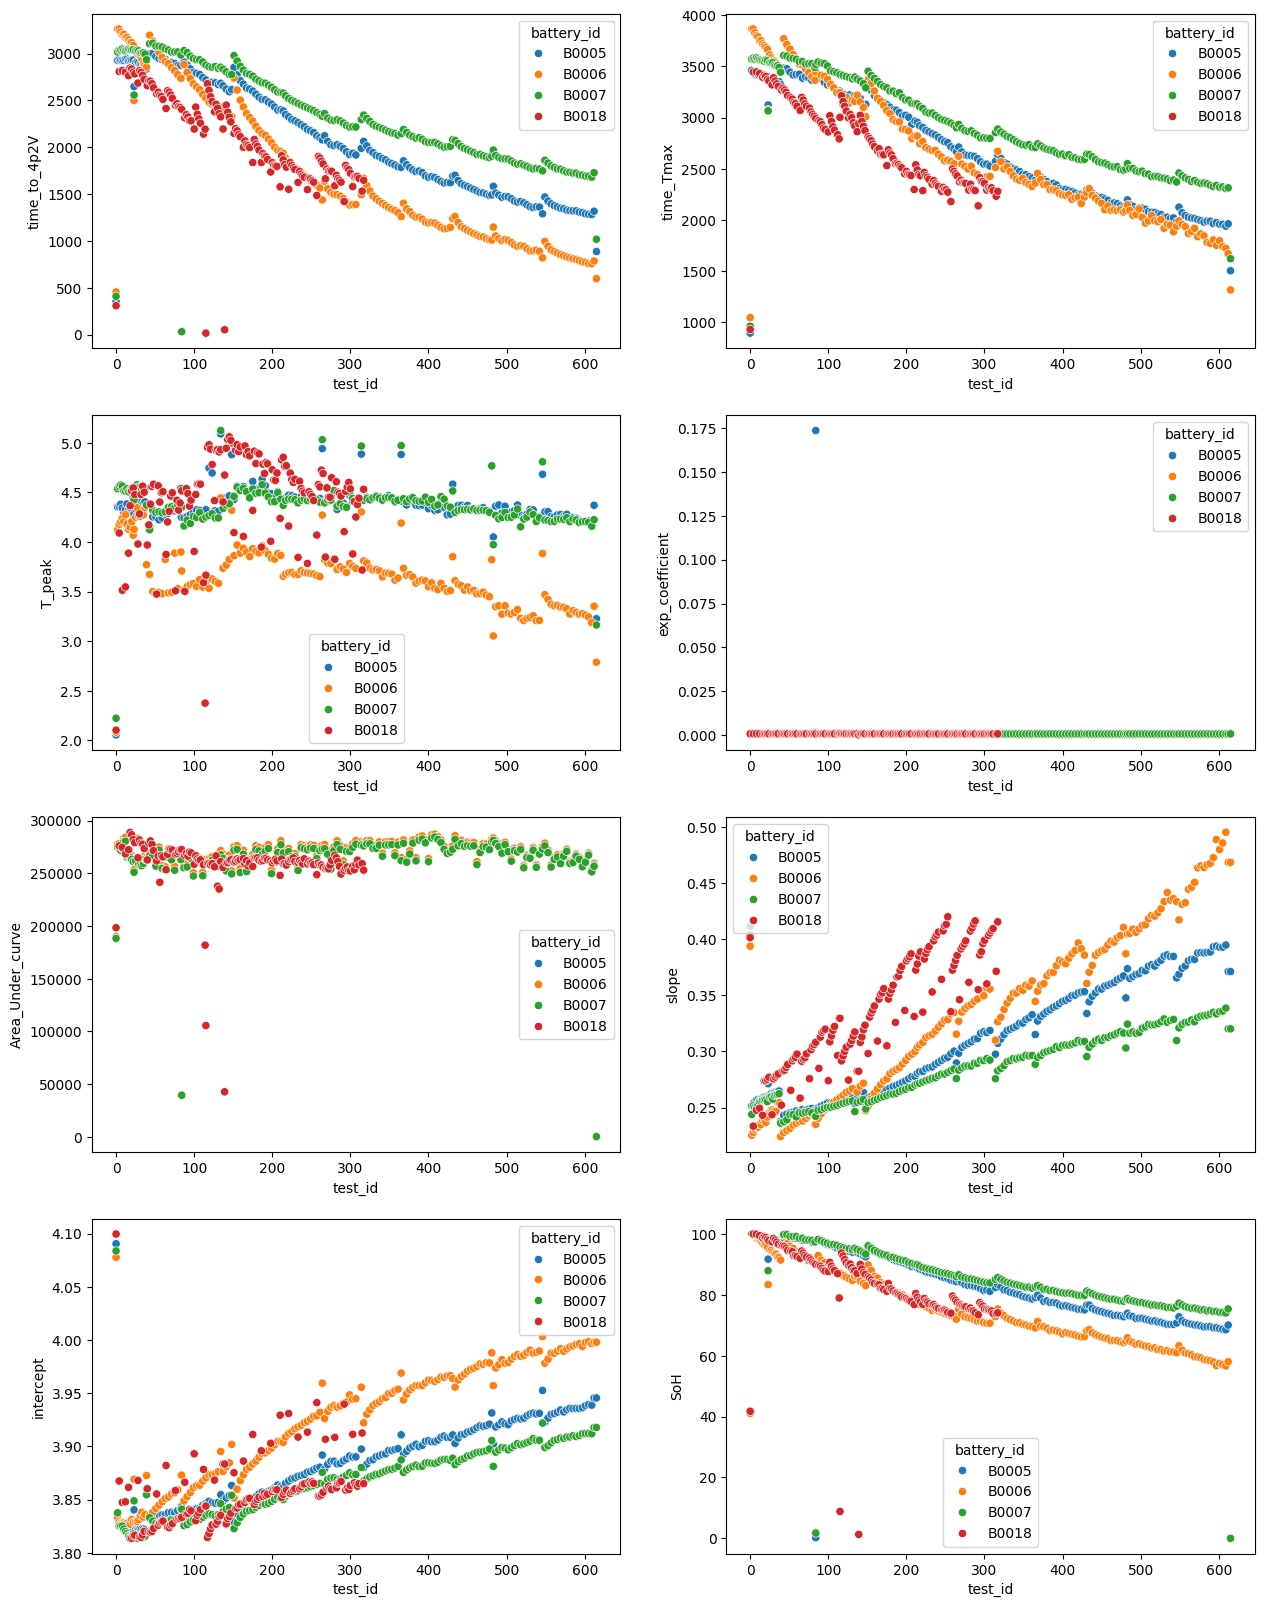

In [68]:
fig,ax = plt.subplots(4,2, figsize=(15,20))
#Visualization of features: 
sns.scatterplot(charge_summary, hue="battery_id", x= "test_id", y="time_to_4p2V", ax=ax[0,0])
sns.scatterplot(charge_summary, hue="battery_id", x= "test_id", y="time_Tmax", ax=ax[0,1])
sns.scatterplot(charge_summary, hue="battery_id", x= "test_id", y="T_peak", ax=ax[1,0])
sns.scatterplot(charge_summary, hue="battery_id", x= "test_id", y="exp_coefficient", ax=ax[1,1])
sns.scatterplot(charge_summary, hue="battery_id", x= "test_id", y="Area_Under_curve", ax=ax[2,0])
sns.scatterplot(charge_summary, hue="battery_id", x= "test_id", y="slope", ax=ax[2,1])
sns.scatterplot(charge_summary, hue="battery_id", x= "test_id", y="intercept", ax=ax[3,0])
sns.scatterplot(charge_summary, hue="battery_id", x= "test_id", y="SoH", ax=ax[3,1])

In [177]:
importlib.reload(utils)
from utils import time_format,preprocessing_meta,battery_cycles_df,continuous_time,current_capacity,visualization_2by2, timeTmax, time_Tmax3,area_under_curve, time_to_voltage, charging_decay, charging_slope, ransac_clean_outliers

In [178]:
charge_summary_clean = charge_summary.copy()
charge_summary_clean = ransac_clean_outliers(charge_summary_clean,"time_to_4p2V")
charge_summary_clean = ransac_clean_outliers(charge_summary_clean,"time_Tmax")
charge_summary_clean = ransac_clean_outliers(charge_summary_clean,"T_peak")
charge_summary_clean = ransac_clean_outliers(charge_summary_clean,"exp_coefficient")
charge_summary_clean = ransac_clean_outliers(charge_summary_clean,"Area_Under_curve")
charge_summary_clean = ransac_clean_outliers(charge_summary_clean,"slope")
charge_summary_clean = ransac_clean_outliers(charge_summary_clean,"intercept")
charge_summary_clean = ransac_clean_outliers(charge_summary_clean,"SoH")

<Axes: xlabel='test_id', ylabel='SoH'>

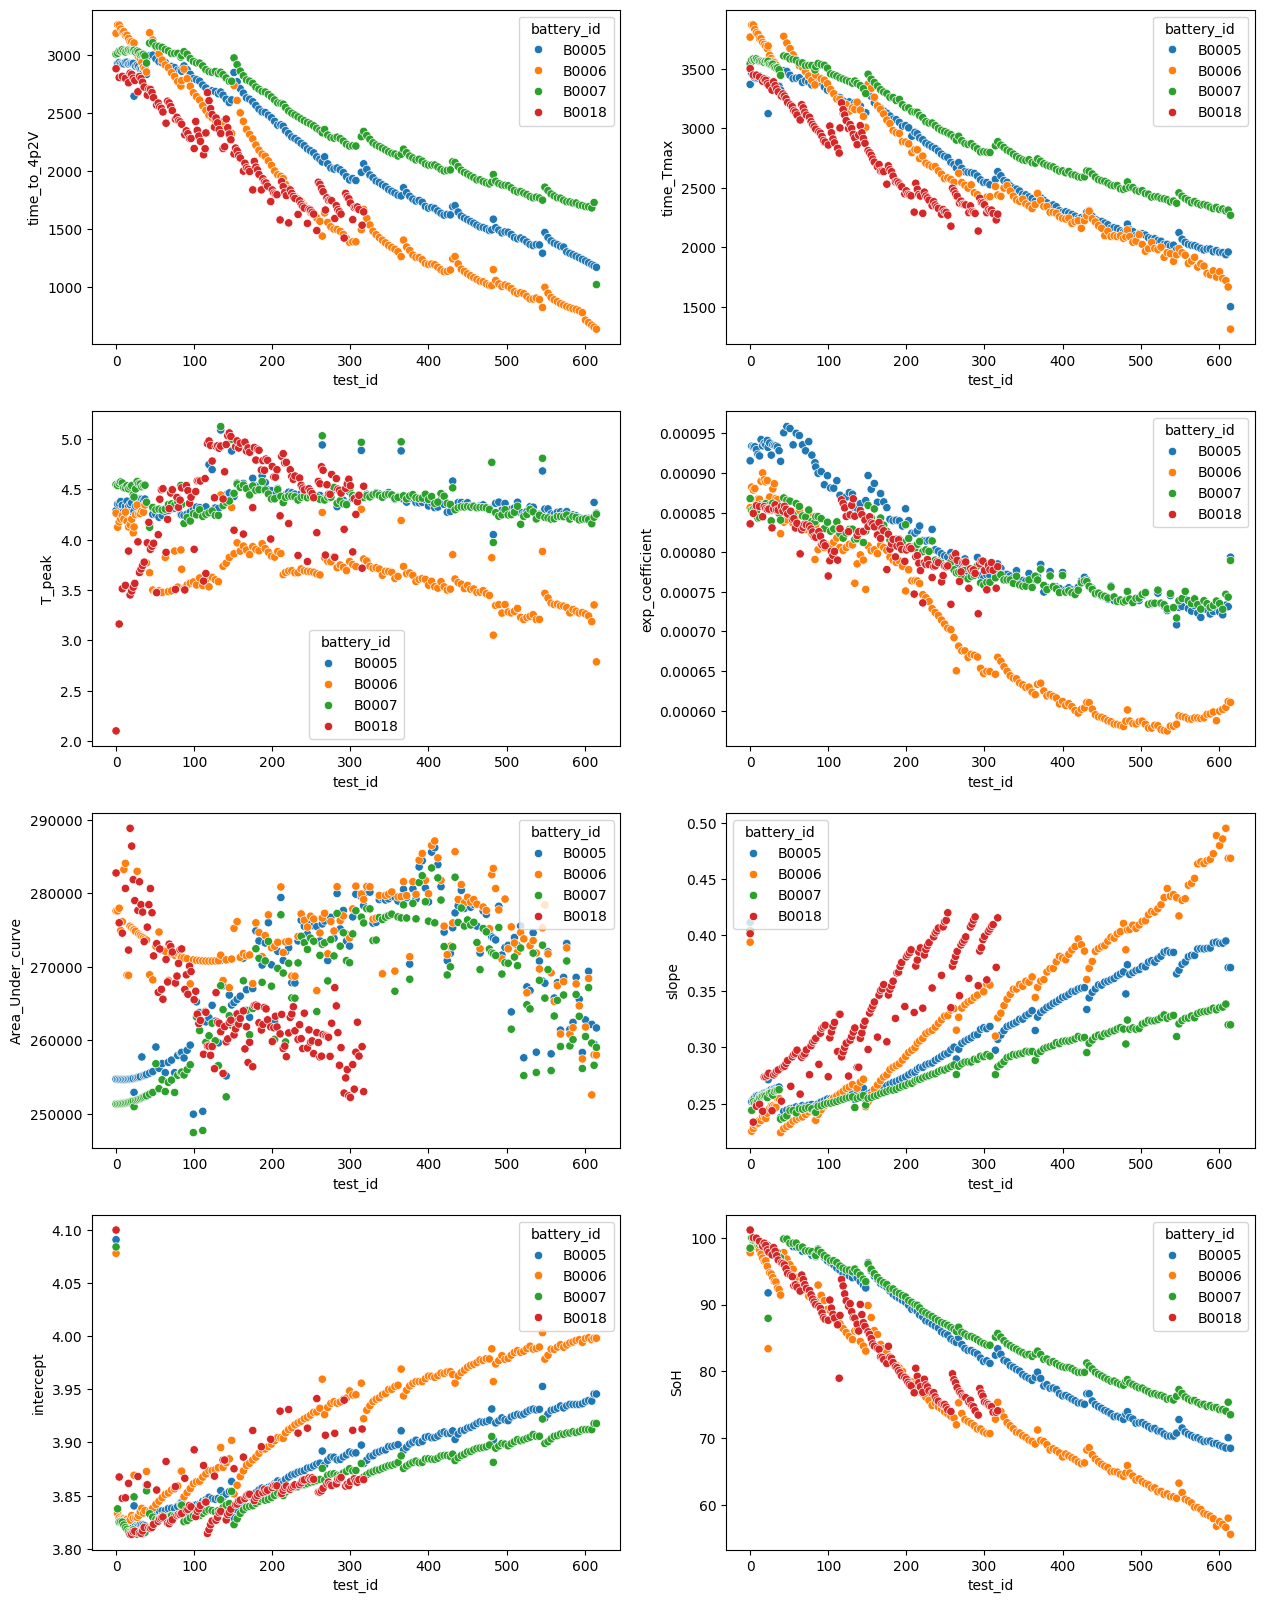

In [179]:
fig,ax = plt.subplots(4,2, figsize=(15,20))
#Visualization of features: 
sns.scatterplot(charge_summary_clean, hue="battery_id", x= "test_id", y="time_to_4p2V", ax=ax[0,0])
sns.scatterplot(charge_summary_clean, hue="battery_id", x= "test_id", y="time_Tmax", ax=ax[0,1])
sns.scatterplot(charge_summary_clean, hue="battery_id", x= "test_id", y="T_peak", ax=ax[1,0])
sns.scatterplot(charge_summary_clean, hue="battery_id", x= "test_id", y="exp_coefficient", ax=ax[1,1])
sns.scatterplot(charge_summary_clean, hue="battery_id", x= "test_id", y="Area_Under_curve", ax=ax[2,0])
sns.scatterplot(charge_summary_clean, hue="battery_id", x= "test_id", y="slope", ax=ax[2,1])
sns.scatterplot(charge_summary_clean, hue="battery_id", x= "test_id", y="intercept", ax=ax[3,0])
sns.scatterplot(charge_summary_clean, hue="battery_id", x= "test_id", y="SoH", ax=ax[3,1])

In [180]:
charge_summary_clean.isna().sum()

battery_id                  0
test_id                     0
time_to_4p2V                0
time_Tmax                   0
T_peak                      0
exp_coefficient             0
Area_Under_curve            0
slope                       0
intercept                   0
SoH                         0
time_to_4p2V_outlier        0
time_Tmax_outlier           0
T_peak_outlier              0
exp_coefficient_outlier     0
Area_Under_curve_outlier    0
slope_outlier               0
intercept_outlier           0
SoH_outlier                 0
dtype: int64

## Features: 
    - time to 4.2 V --> charge acceptance 
    - time to T_max --> thermal kinetics
    - T_peak --> heat generation
    - exp_coefcient during decay --> relaxation dynamics
    - charge duration? 
    - mean charging voltage? 
    - thermal area
    - slope CC phase
    - intercept CC phase
    - SoH --> target

## XGBOOST

In [181]:
charge_summary_clean.columns

Index(['battery_id', 'test_id', 'time_to_4p2V', 'time_Tmax', 'T_peak',
       'exp_coefficient', 'Area_Under_curve', 'slope', 'intercept', 'SoH',
       'time_to_4p2V_outlier', 'time_Tmax_outlier', 'T_peak_outlier',
       'exp_coefficient_outlier', 'Area_Under_curve_outlier', 'slope_outlier',
       'intercept_outlier', 'SoH_outlier'],
      dtype='str')

In [228]:

#Train and test sets
features_charging = charge_summary_clean.copy().drop(['time_to_4p2V_outlier', 'time_Tmax_outlier', 'T_peak_outlier',       'exp_coefficient_outlier', 'Area_Under_curve_outlier','intercept_outlier', 'SoH_outlier','slope_outlier'],axis=1)
X= features_charging.drop("SoH",axis=1)
y= features_charging[["battery_id","SoH"]]

#train 
X_train = X.loc[X["battery_id"].isin(["B0005","B0006","B0018"])]
y_train=y.loc[y["battery_id"].isin(["B0005","B0006","B0018"])]

#test 
X_test = X.loc[X["battery_id"].isin(["B0007"])]
y_test=y.loc[y["battery_id"].isin(["B0007"])]
X

,battery_id,test_id,time_to_4p2V,time_Tmax,T_peak,exp_coefficient,Area_Under_curve,slope,intercept
0,B0005,0,2887.668821,3367.626915,4.290716,0.000915,254702.789362,0.411291,4.090538
1,B0005,2,2929.156000,3460.203000,4.355224,0.000934,254677.853443,0.251741,3.833725
2,B0005,4,2938.359000,3444.094000,4.363093,0.000933,254659.808297,0.253855,3.829970
3,B0005,6,2928.453000,3421.593000,4.380745,0.000933,254648.539412,0.255395,3.828814
4,B0005,8,2927.859000,3420.093000,4.343384,0.000930,254643.932932,0.256845,3.826681
...,...,...,...,...,...,...,...,...,...
639,B0018,307,1689.891000,2303.657000,4.252029,0.000778,258366.545551,0.405407,3.863868
640,B0018,309,1690.344000,2313.719000,4.378193,0.000787,262453.718075,0.407782,3.862654
641,B0018,311,1668.093000,2285.656000,4.442542,0.000777,257840.531553,0.409375,3.865032
642,B0018,315,1532.422000,2231.265000,3.717971,0.000755,259127.564267,0.371359,3.912636


In [ ]:
#train 
X_train = X_train.drop("battery_id",axis=1)
y_train=y_train.drop("battery_id",axis=1)

#test 
X_test = X_test.drop("battery_id",axis=1)
y_test= y_test.drop("battery_id",axis=1)

In [230]:
from sklearn import preprocessing
X_scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = X_scaler.transform(X_train)
X_test_scaled = X_scaler.transform(X_test)


In [231]:
y_scaler=preprocessing.StandardScaler()
y_train_norm = y_scaler.fit_transform(y_train.values.reshape(-1,1))


In [191]:
# A parameter grid for XGBoost
params = {
        'max_depth': [3, 4, 5],
        'n_estimators':[100,300,500],
        'learning_rate': [0.01,0.1,0.5]
        }

In [232]:
#Calling XGBoost

XGBmodel = XGBRegressor(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)
XGBmodel.fit(X_train_scaled,y_train_norm)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [235]:
y_pred_norm = XGBmodel.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_norm.reshape(-1,1)).ravel()

In [236]:
model_metrics = {}

In [237]:
#Evaluation metrics
mae_XGB = mean_absolute_error(y_test,y_pred)
r2_XGB = r2_score(y_test,y_pred)
residuals_XGB = y_test.values.ravel()-y_pred
std_XGB = np.std(residuals_XGB)
model_metrics["XGB1"] = {"r2":r2_XGB, "mae": mae_XGB, "std_XGB":std_XGB}
print("MAE")
print(mae_XGB)
print("R2-score")
print(r2_XGB)
print("std-deviation")
print(std_XGB)



MAE
2.1422219276428223
R2-score
0.9222554564476013
std-deviation
2.358660909708245


In [238]:
y_test.shape
y_test.values.ravel().shape

(170,)

In [239]:
y_pred_norm.shape

(170,)

In [240]:
results_XGB = pd.DataFrame()
results_XGB["X_test"]=X_test["test_id"]
results_XGB["y_test"]=y_test.values.ravel()
results_XGB["y_pred_XGB"] = y_pred
results_XGB["residuals"] = y_test.values.ravel()-y_pred


<Axes: xlabel='X_test', ylabel='y_test'>

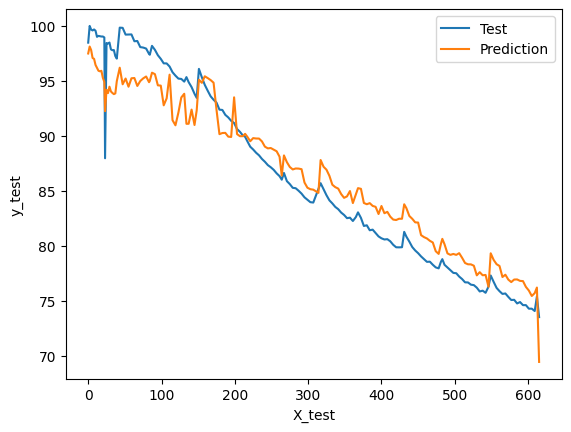

In [241]:
sns.lineplot(data= results_XGB, x= "X_test", y= "y_test", label="Test")
sns.lineplot(data= results_XGB, x= "X_test", y= "y_pred_XGB", label ="Prediction")

In [242]:
print(XGBmodel.feature_importances_)
print(X_train.columns)

[0.00435881 0.5254535  0.34956267 0.00174447 0.0330608  0.00055633
 0.00532766 0.0799358 ]
Index(['test_id', 'time_to_4p2V', 'time_Tmax', 'T_peak', 'exp_coefficient',
       'Area_Under_curve', 'slope', 'intercept'],
      dtype='str')


## Adaptive boosting

In [243]:
#Calling ADABoost

Adamodel_khan = AdaBoostRegressor(
    n_estimators=110,
    random_state= 42,
    learning_rate=0.001,
)
Adamodel_khan.fit(X_train_scaled,y_train_norm)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",110
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.001
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [244]:
ada_y_pred_norm = Adamodel_khan.predict(X_test_scaled)
ada_y_pred = y_scaler.inverse_transform(ada_y_pred_norm.reshape(-1,1)).ravel()


In [245]:
#Evaluation metrics
mae_ada = mean_absolute_error(y_test,ada_y_pred)
r2_ada = r2_score(y_test,ada_y_pred)
residuals_ada = y_test.values.ravel()-ada_y_pred
std_ada = np.std(residuals_ada)
model_metrics["Ada1"] = {"r2":r2_ada, "mae": mae_ada, "std_XGB":std_ada}
print("MAE")
print(mae_ada)
print("R2-score")
print(r2_ada)
print("std-deviation")
print(std_ada)

MAE
1.590696503723223
R2-score
0.9492082182509198
std-deviation
1.8035815357120026


In [246]:
results_Ada = pd.DataFrame()
results_Ada["X_test"]=X_test["test_id"]
results_Ada["y_test"]=y_test.values.ravel()
results_Ada["y_pred_ada"] = ada_y_pred
results_Ada["residuals"] = y_test.values.ravel()-ada_y_pred

<Axes: xlabel='X_test', ylabel='y_test'>

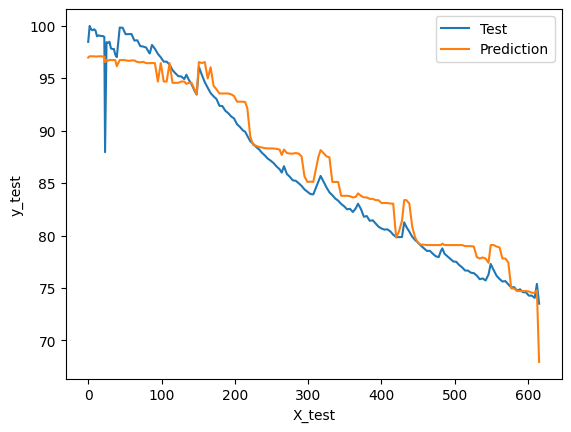

In [247]:
sns.lineplot(data= results_Ada, x= "X_test", y= "y_test", label="Test")
sns.lineplot(data= results_Ada, x= "X_test", y= "y_pred_ada", label ="Prediction")

## Supporting Vector machine

In [248]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline

#call regressor 
SVR_model = SVR(
    kernel = 'rbf',
    C=10,
    gamma = "scale",
    epsilon = 0.02
)
SVR_model.fit(X_train_scaled,y_train_norm)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.02
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [249]:
svr_y_pred_norm = SVR_model.predict(X_test_scaled)
svr_y_pred = y_scaler.inverse_transform(svr_y_pred_norm.reshape(-1,1)).ravel()

In [250]:
#Evaluation metrics
mae_svr = mean_absolute_error(y_test,svr_y_pred)
r2_svr = r2_score(y_test,svr_y_pred)
residuals_svr = y_test.values.ravel()-svr_y_pred
std_svr = np.std(residuals_svr)
model_metrics["SVR1"] = {"r2":r2_svr, "mae": mae_svr, "std_XGB":std_svr}
print("MAE")
print(mae_svr)
print("R2-score")
print(r2_svr)
print("std-deviation")
print(std_svr)


MAE
1.7766389230865964
R2-score
0.9491083252286822
std-deviation
0.7697978519497699


In [251]:
results_SVR = pd.DataFrame()
results_SVR["X_test"]=X_test["test_id"]
results_SVR["y_test"]=y_test.values.ravel()
results_SVR["y_pred_svr"] = svr_y_pred
results_SVR["residuals"] = y_test.values.ravel()-svr_y_pred

<Axes: xlabel='X_test', ylabel='y_test'>

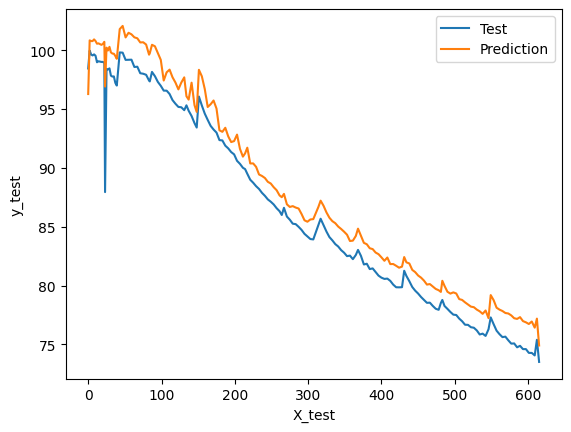

In [252]:
sns.lineplot(data= results_SVR, x= "X_test", y= "y_test", label="Test")
sns.lineplot(data= results_SVR, x= "X_test", y= "y_pred_svr", label ="Prediction")

## Hyperparameter Tuning with GridSearch